In [173]:
import cv2
import numpy as np
import configparser
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import tkinter as tk

## Konfiguráció beolvasása

In [174]:
config = configparser.ConfigParser()
config.read('config.ini')

IMG_SIZE = int(config['MODEL']['image_size'])
THRESHOLD = float(config['THRESHOLDS']['cosine_similarity_threshold'])

## Képek betöltése

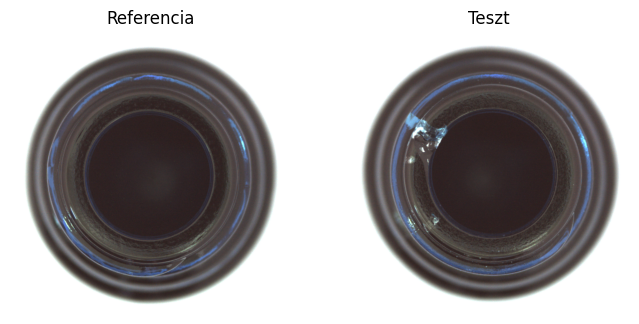

In [175]:
# Kép elérési utak
ref_path = "images/bottle_000.png"
test_path = "images/bottle_001.png"

# Betöltés és RGB konverzió
ref_img = cv2.imread(ref_path)
test_img = cv2.imread(test_path)

# Megjelenítés
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(ref_img)
plt.title("Referencia")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(test_img)
plt.title("Teszt")
plt.axis("off")
plt.show()

## Előfeldolgozás

In [176]:
#Egyforma méretre hozás, ResNet50 → 224×224
ref_resized = cv2.resize(ref_img, (IMG_SIZE, IMG_SIZE))
test_resized = cv2.resize(test_img, (IMG_SIZE, IMG_SIZE))

#ref_input = np.expand_dims(ref_resized, axis=0)
#ref_input = preprocess_input(ref_input)

#test_input = np.expand_dims(test_resized, axis=0)
#test_input = preprocess_input(test_input)

#print("Előfeldolgozás kész.")
#print("Shape:", ref_input.shape)

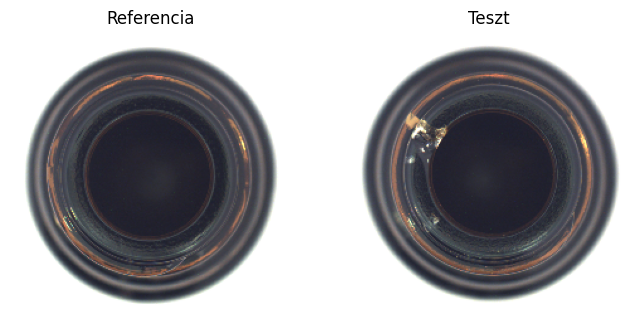

In [177]:
#Színtér konverzió, szürkéssel ki lehetne próbálni

ref_img_rgb = cv2.cvtColor(ref_resized, cv2.COLOR_BGR2RGB)
test_img_rgb = cv2.cvtColor(test_resized, cv2.COLOR_BGR2RGB)

#Megjelenítés
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(ref_img_rgb)
plt.title("Referencia")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(test_img_rgb)
plt.title("Teszt")
plt.axis("off")
plt.show()

In [178]:
#Zajszűrést lehet alkalmazni majd, de lehet hogy csak hátrányosan befolyásolja a hasonlóságot

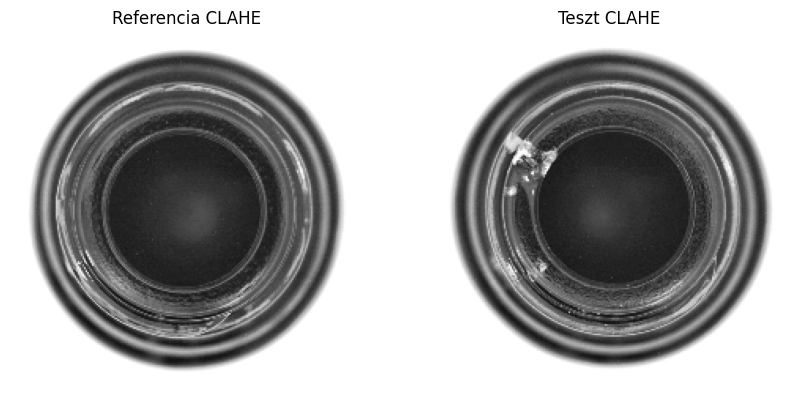

In [179]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def clahe_rgb(img, clipLimit=2.0, tileGridSize=(8,8)):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    clahe_img = clahe.apply(gray)
    clahe_rgb = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2RGB)
    return clahe_rgb

ref_img_clahe = clahe_rgb(ref_img_rgb)
test_img_clahe = clahe_rgb(test_img_rgb)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(ref_img_clahe)
plt.title("Referencia CLAHE")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(test_img_clahe)
plt.title("Teszt CLAHE")
plt.axis("off")
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096583611610584..2.6399999999999997].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8267831149927218..2.6399999999999997].


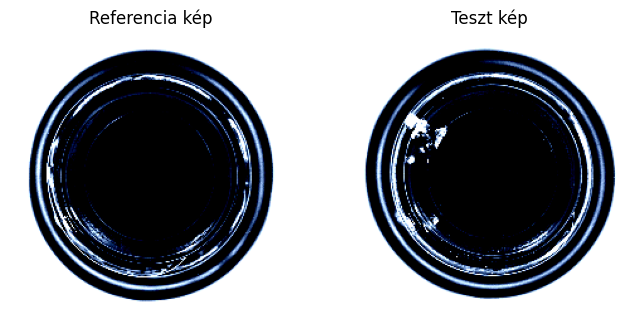

In [180]:
#Normalizálás
#Pixel értékek [0,1] tartományba: img/255.0
#CNN-eknél gyakran mean/std szerinti normalizáció ImageNet alapján:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

def normalize_image(img):
    img = img / 255.0
    img = (img - mean) / std
    return img

ref_img_normalized = normalize_image(ref_img_clahe)
test_img_normalized = normalize_image(test_img_clahe)

#Megjelenítés
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(ref_img_normalized)
plt.title('Referencia kép')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(test_img_normalized)
plt.title('Teszt kép')
plt.axis('off')

plt.show()


Jellemző-kivonatoló modell felépítve.
Bemeneti shape a modellnek: (1, 224, 224, 3)
1/1 [==============================] - 0s 57ms/step
Kimeneti jellemzőtérkép shape: (1, 14, 14, 1024)
Anomália térkép shape: (14, 14)


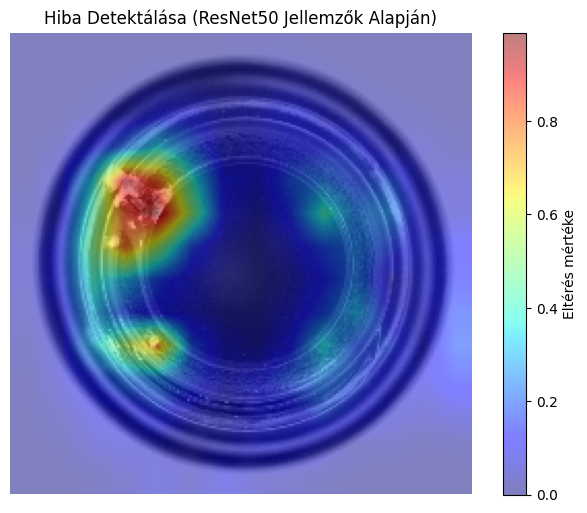

In [181]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model

# Töltsük be a ResNet50-et ImageNet súlyokkal, de a teteje (klasszifikáló) nélkül
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False # Nem akarjuk tanítani, csak használni

# Válasszunk egy réteget, aminek a kimenetét összehasonlítjuk
# A 'conv5_block3_out' egy jó választás, ez az utolsó konvolúciós blokk
# Ennek kimenete (224x224 bemenet esetén) (None, 7, 7, 2048)
feature_layer_name = 'conv4_block1_out' 

# Hozzunk létre egy új modellt, ami bemenetként a képet kapja,
# kimenetként pedig a választott réteg aktivációit adja
feature_extractor = Model(inputs=base_model.input, 
                          outputs=base_model.get_layer(feature_layer_name).output)

print("\nJellemző-kivonatoló modell felépítve.")

# --- 3. LÉPÉS: JELLEMZŐTÉRKÉPEK KINYERÉSE ÉS ÖSSZEHASONLÍTÁSA ---

# A modell 'predict' metódusa "batch"-et vár bemenetként.
# Nekünk most 1 elemű batch-eink lesznek.
# Használjuk az np.expand_dims-t, amit te is kommenteltél!
ref_input = np.expand_dims(ref_img_normalized, axis=0)
test_input = np.expand_dims(test_img_normalized, axis=0)

print("Bemeneti shape a modellnek:", ref_input.shape)

# Futtassuk át a képeket a modellen
ref_features = feature_extractor.predict(ref_input)
test_features = feature_extractor.predict(test_input)

print("Kimeneti jellemzőtérkép shape:", ref_features.shape) # (1, 7, 7, 2048)

# Számoljuk ki a két jellemzőtérkép közötti különbséget
# Először vegyük a különbség négyzetét, hogy minden pozitív legyen
# (A .squeeze() eltávolítja az 1-es batch dimenziót)
feature_diff_sq = (np.squeeze(ref_features) - np.squeeze(test_features))**2

# Most aggregáljuk a 2048 csatornát.
# Átlagoljuk vagy összegezzük őket minden (7, 7) pozíción.
# Ez egy (7, 7)-es "anomália térképet" ad.
anomaly_map = np.mean(feature_diff_sq, axis=-1) # Átlagolás a csatornák mentén

print("Anomália térkép shape:", anomaly_map.shape)

# --- 4. LÉPÉS: HŐTÉRKÉP (HEATMAP) KÉSZÍTÉSE ÉS MEGJELENÍTÉSE ---

# 1. Normalizáljuk az anomália térképet [0, 1] tartományba, hogy hőtérkép lehessen
anomaly_map_normalized = (anomaly_map - np.min(anomaly_map)) / (np.max(anomaly_map) - np.min(anomaly_map))

# 2. Méretezzük fel a kis (7, 7)-es térképet az eredeti (224, 224)-es képméretre
heatmap = cv2.resize(anomaly_map_normalized, (IMG_SIZE, IMG_SIZE))

# 3. Megjelenítés: Helyezzük a hőtérképet az eredeti teszt képre
plt.figure(figsize=(8, 6))
plt.imshow(test_img_clahe) # Az eredeti (CLAHE) teszt kép
plt.imshow(heatmap, cmap='jet', alpha=0.5) # Áttetsző hőtérkép rajta
plt.title("Hiba Detektálása (ResNet50 Jellemzők Alapján)")
plt.colorbar(label="Eltérés mértéke")
plt.axis('off')
plt.show()

1/1 [==============================] - 0s 35ms/step


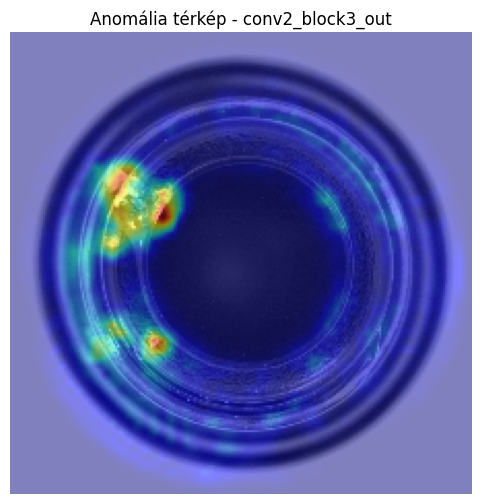

1/1 [==============================] - 0s 66ms/step


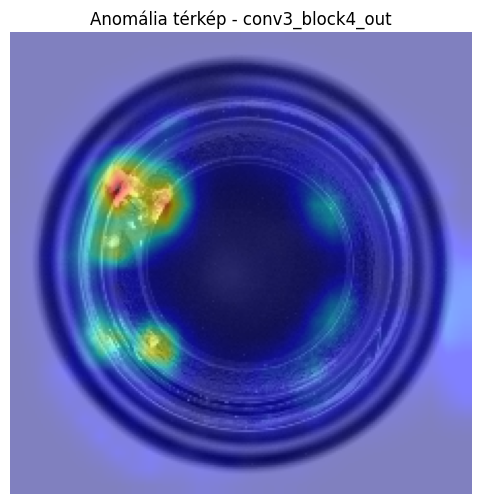

1/1 [==============================] - 0s 51ms/step


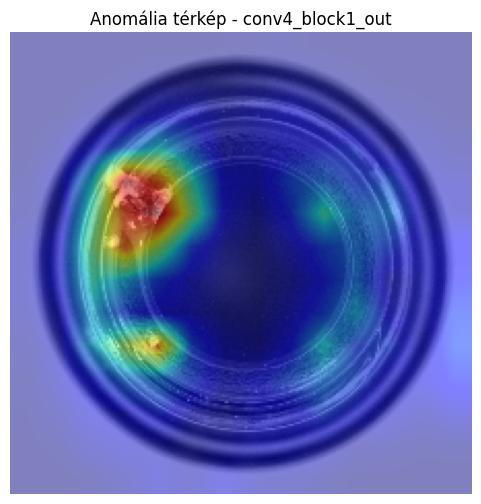

1/1 [==============================] - 0s 123ms/step


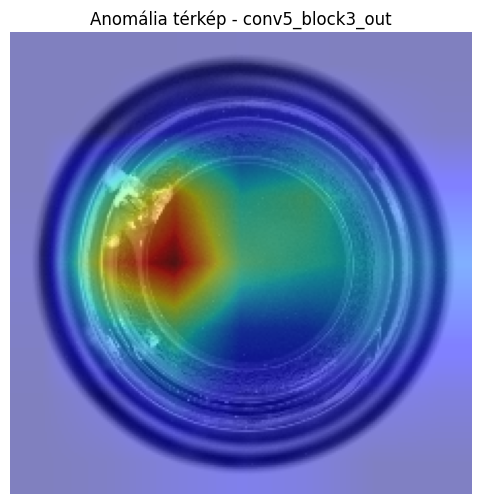

In [182]:
#Több réteg kipróbálása

layer_names = [
    'conv2_block3_out',
    'conv3_block4_out',
    'conv4_block1_out',
    'conv5_block3_out'
]

for layer_name in layer_names:
    # Feature extractor modell
    feature_extractor = Model(inputs=base_model.input,
                              outputs=base_model.get_layer(layer_name).output)
    
    # Kimenetek előrejelzése
    ref_features = feature_extractor.predict(ref_input)
    test_features = feature_extractor.predict(test_input)
    
    # Anomália térkép
    feature_diff_sq = (np.squeeze(ref_features) - np.squeeze(test_features))**2
    anomaly_map = np.mean(feature_diff_sq, axis=-1)
    anomaly_map_normalized = (anomaly_map - np.min(anomaly_map)) / (np.max(anomaly_map) - np.min(anomaly_map))
    
    # Méretezés az eredeti képhez
    heatmap = cv2.resize(anomaly_map_normalized, (IMG_SIZE, IMG_SIZE))
    
    # Megjelenítés
    plt.figure(figsize=(6,6))
    plt.imshow(test_img_clahe)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    plt.title(f"Anomália térkép - {layer_name}")
    plt.axis('off')
    plt.show()


# Összehasonlítás távolságok alapján

In [183]:
# A referencia kép és a bemeneti kép közötti hasonlóság kiszámítása többféle módon, 
#1. Cosine Similarity

ref_vector = ref_features.flatten().reshape(1, -1)
test_vector = test_features.flatten().reshape(1, -1)
cosine_sim = cosine_similarity(ref_vector, test_vector)[0][0]
print(f"Cosine Similarity: {cosine_sim:.4f}")


#2. Euclidean Distance

euclidean_dist = np.linalg.norm(ref_vector - test_vector)
print(f"Euclidean Distance: {euclidean_dist:.4f}")

#3. Manhattan Distance
manhattan_dist = np.sum(np.abs(ref_vector - test_vector))
print(f"Manhattan Distance: {manhattan_dist:.4f}")

Cosine Similarity: 0.9429
Euclidean Distance: 124.7725
Manhattan Distance: 9530.5010


## Modell betöltése

In [184]:
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

# Feature extraction
ref_feat = base_model.predict(ref_input, verbose=0).flatten()
test_feat = base_model.predict(test_input, verbose=0).flatten()

print("Feature extraction kész. Dimenzió:", ref_feat.shape)

Feature extraction kész. Dimenzió: (2048,)


In [185]:
similarity = cosine_similarity([ref_feat], [test_feat])[0][0]
result = "Hibátlan" if similarity > (1 - THRESHOLD) else "Hibás"

print(f"Képek közötti hasonlóság: {similarity:.4f}")
print(f"Eredmény: {result}")

Képek közötti hasonlóság: 0.9867
Eredmény: Hibátlan
